<span><a href="https://colab.research.google.com/github/gse-unil/2026_Geoinformatique_II/blob/main/tps/python/project_example_landslides.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/></a> <a href="https://www.kaggle.com/kernels/welcome?src=https://github.com/gse-unil/2026_Geoinformatique_II/blob/main/tps/python/project_example_landslides.ipynb" target="_parent"><img src="https://img.shields.io/badge/Open%20in-Kaggle-20BEFF?logo=kaggle&logoColor=white" alt="Open in Kaggle"/></a> <a href="https://renkulab.io/p/fatihi.ayb/geoinformatique-ii/" target="_parent"><img src="https://renkulab.io/renku-badge.svg" alt="Launch on Renku"/></a></span>

> **Exécution dans le cloud** : ce notebook peut aussi tourner dans le cloud (Colab, Kaggle, Renku).
> Avant de lancer les cellules, télécharge `project_landslides.gpkg` depuis le dossier OneDrive du cours et dépose-le dans le répertoire de travail du notebook (Colab : panneau 📁 → *Upload* ; Kaggle : *File → Upload* ; Renku : déjà dans le projet).
> Procédure complète : [docs/cloud-badges.md](https://github.com/gse-unil/2026_Geoinformatique_II/blob/main/docs/cloud-badges.md).


# Exemple de projet — Glissements de terrain en Suisse

Ce notebook est un **exemple de projet final**, qui illustre l'enchaînement d'étapes attendu pour le projet : chargement des données, analyse statistique, définition et entraînement d'un modèle avec quantification de l'erreur, puis export des résultats.

**Question posée** : peut-on prédire si un lieu est sujet à un glissement de terrain (présence / absence) à partir de variables topographiques simples (pente, courbure, distance aux infrastructures, etc.) — et ce modèle **généralise-t-il à des régions qu'il n'a jamais vues** ?

**Données** : tout est regroupé dans un unique fichier, `project_landslides.gpkg` — préparé en amont (harmonisation des systèmes de coordonnées, recadrage sur la Suisse, nettoyage) de sorte que ce notebook n'a besoin **que de ce seul fichier**, pas d'un dossier de shapefiles et de rasters épars.

| Couche vectorielle | Contenu |
|---|---|
| `switzerland` | Frontière nationale |
| `regions` | 4 régions physiographiques (Alpes, Préalpes, Jura, Plateau) |
| `landslides_ch` | Inventaire des glissements de terrain (WSL), déjà recadré sur la Suisse |
| `cities`, `lakes` | Contexte cartographique |
| `classification_points` | Résultats de la classification (écrite en partie 5) |

| Table raster (100 m, déjà recadrées) | Contenu |
|---|---|
| `dem`, `slope`, `twi`, `plancurv`, `profcurv` | Variables topographiques |
| `dist_routes`, `dist_autoroutes`, `dist_fussweg` | Distances aux infrastructures |
| `flow_acc`, `flow_dir` | Hydrologie |
| `geology`, `landcover` | Variables catégorielles |
| `scp_map` | Carte de susceptibilité de référence (contexte, non utilisée comme prédicteur) |


In [3]:
import geopandas as gpd
import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from shapely.geometry import Point

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay,
)
import xgboost as xgb

import warnings
warnings.filterwarnings('ignore', message='.*PROJ.*')

GPKG = 'project_landslides.gpkg'

# Tables raster disponibles dans le GeoPackage (100 m, Suisse entière, déjà recadrées).
RASTER_TABLES = [
    'dem', 'slope', 'twi', 'plancurv', 'profcurv',
    'dist_routes', 'dist_autoroutes', 'dist_fussweg',
    'flow_acc', 'flow_dir', 'geology', 'landcover', 'scp_map',
]

---
## 1. Chargement des données

### 1.1 Couches vectorielles

Une seule source, un seul CRS : toutes les couches du GeoPackage sont déjà en LV03 (EPSG:21781), pas d'étape de préparation à refaire ici.

In [4]:
suisse         = gpd.read_file(GPKG, layer='switzerland')
regions        = gpd.read_file(GPKG, layer='regions')
villes         = gpd.read_file(GPKG, layer='cities')
lacs           = gpd.read_file(GPKG, layer='lakes')
glissements_ch = gpd.read_file(GPKG, layer='landslides_ch')

for nom, gdf in [('Suisse', suisse), ('Régions', regions), ('Villes', villes),
                  ('Lacs', lacs), ('Glissements', glissements_ch)]:
    print(f"{nom:<12}  {str(gdf.shape):<10}  CRS: {gdf.crs.to_epsg()}  geom: {gdf.geom_type.unique()[0]}")

Suisse        (1, 12)     CRS: 21781  geom: Polygon
Régions       (4, 13)     CRS: 21781  geom: MultiPolygon
Villes        (3, 2)      CRS: 21781  geom: Point
Lacs          (69, 13)    CRS: 21781  geom: Polygon
Glissements   (3732, 21)  CRS: 21781  geom: Point


### 1.2 Tables raster

Les rasters vivent dans le même fichier, sous forme de tables (extension GeoPackage *2D gridded coverage*). On y accède avec `rasterio` via une chaîne de connexion `GPKG:chemin:nom_table`, exactement comme on ouvrirait un `.tif`.

In [5]:
with rasterio.open(f'GPKG:{GPKG}:dem') as src:
    print(f"Table 'dem' : {src.width} x {src.height} pixels, résolution {src.res[0]:.0f} m, CRS {src.crs}")

print(f"\n{len(RASTER_TABLES)} tables raster disponibles : {', '.join(RASTER_TABLES)}")

Table 'dem' : 3476 x 2198 pixels, résolution 100 m, CRS EPSG:21781

13 tables raster disponibles : dem, slope, twi, plancurv, profcurv, dist_routes, dist_autoroutes, dist_fussweg, flow_acc, flow_dir, geology, landcover, scp_map


### 1.3 Carte nationale, par région physiographique

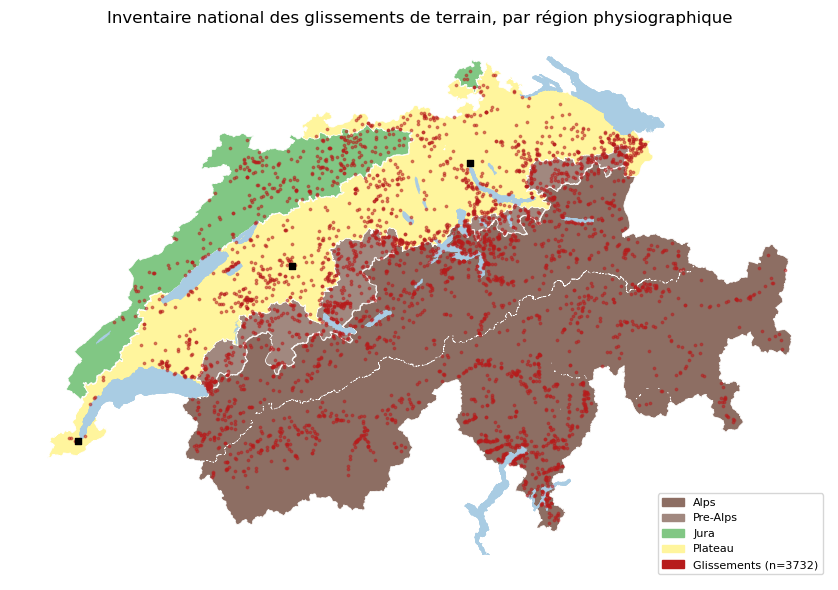

In [6]:
fig, ax = plt.subplots(figsize=(9, 6))

couleurs_regions = {'Alps': '#8d6e63', 'Pre-Alps': '#a1887f', 'Jura': '#81c784', 'Plateau': '#fff59d'}
for _, row in regions.iterrows():
    gpd.GeoSeries([row.geometry], crs=regions.crs).plot(
        ax=ax, color=couleurs_regions[row['Regiona']], edgecolor='white', linewidth=0.5,
    )
lacs.plot(ax=ax, color='#a9cce3', edgecolor='none')
glissements_ch.plot(ax=ax, color='#b71c1c', markersize=3, alpha=0.5)
villes.plot(ax=ax, color='black', markersize=15, marker='s')

patches = [mpatches.Patch(color=c, label=r) for r, c in couleurs_regions.items()]
patches.append(mpatches.Patch(color='#b71c1c', label=f'Glissements (n={len(glissements_ch)})'))
ax.legend(handles=patches, loc='lower right', fontsize=8)
ax.set_title("Inventaire national des glissements de terrain, par région physiographique", fontsize=12)
ax.set_axis_off()
plt.tight_layout()
plt.show()

---
## 2. Étude statistique de l'inventaire des glissements

On explore l'inventaire avant de passer à la modélisation : répartition de l'ampleur des dommages, évolution temporelle, distribution du coût des dommages, et répartition par région.

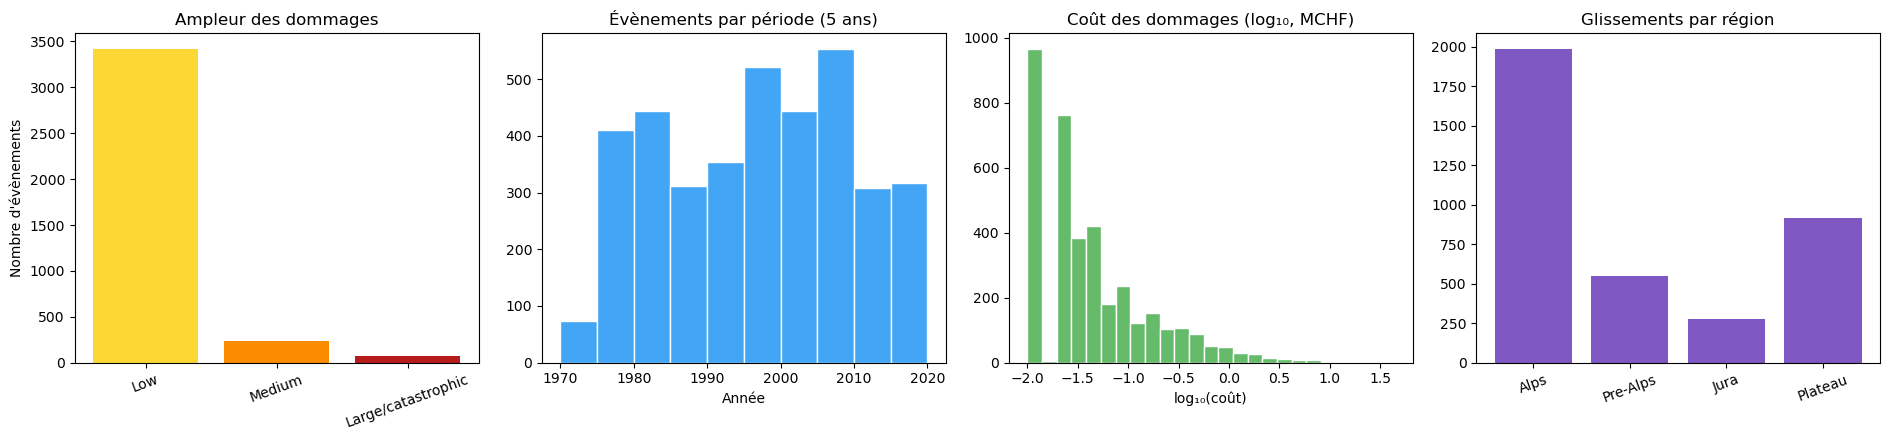

Coût médian des dommages par catégorie d'ampleur (MCHF) :
Dmgext
Low                   0.02
Medium                0.63
Large/catastrophic    2.75
Name: Totdmg, dtype: float64


In [7]:
fig, axes = plt.subplots(1, 4, figsize=(19, 4.5))

# --- Ampleur des dommages ---
ordre = ['Low', 'Medium', 'Large/catastrophic']
compte = glissements_ch['Dmgext'].value_counts().reindex(ordre)
axes[0].bar(compte.index, compte.values, color=['#fdd835', '#fb8c00', '#b71c1c'])
axes[0].set_title("Ampleur des dommages")
axes[0].set_ylabel("Nombre d'évènements")
axes[0].tick_params(axis='x', rotation=20)

# --- Évolution temporelle ---
annees = pd.to_datetime(glissements_ch['Date'], format='%d.%m.%Y', errors='coerce').dt.year
axes[1].hist(annees.dropna(), bins=range(1970, 2025, 5), color='#42a5f5', edgecolor='white')
axes[1].set_title("Évènements par période (5 ans)")
axes[1].set_xlabel("Année")

# --- Coût des dommages (log10, en millions CHF) ---
cout = pd.to_numeric(
    glissements_ch['Totdmg'].astype(str).str.replace(',', '.', regex=False),
    errors='coerce',
)
axes[2].hist(np.log10(cout.dropna()), bins=25, color='#66bb6a', edgecolor='white')
axes[2].set_title("Coût des dommages (log₁₀, MCHF)")
axes[2].set_xlabel("log₁₀(coût)")

# --- Répartition par région ---
region_glissements = gpd.sjoin(glissements_ch, regions[['Regiona', 'geometry']], how='left', predicate='within')
compte_region = region_glissements['Regiona'].value_counts().reindex(['Alps', 'Pre-Alps', 'Jura', 'Plateau'])
axes[3].bar(compte_region.index, compte_region.values, color='#7e57c2')
axes[3].set_title("Glissements par région")
axes[3].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

print("Coût médian des dommages par catégorie d'ampleur (MCHF) :")
print(cout.groupby(glissements_ch['Dmgext']).median().reindex(ordre).round(3))

Le coût des dommages est très asymétrique (quelques évènements catastrophiques dominent le total) et n'est connu qu'aux emplacements des glissements déjà survenus. Pour la partie modélisation, on formule donc plutôt le problème comme une **classification** : à un emplacement donné, y a-t-il eu — ou non — un glissement de terrain ?

---
## 3. Définir le problème de classification

C'est l'approche la plus classique en cartographie de la susceptibilité aux glissements de terrain (modèle *présence/absence*).

### 3.1 Points de présence et région physiographique

Les glissements chargés en partie 1 (`glissements_ch`) constituent les points de **présence** (label = 1). La couche `landslides_ch` ne porte pas leur région physiographique : on la leur attribue par jointure spatiale (`gpd.sjoin`) — elle servira à la fois à équilibrer les pseudo-absences (§3.2) et de groupe de validation croisée (§3.6).

In [8]:
glissements_ch = gpd.sjoin(
    glissements_ch, regions[['Regiona', 'geometry']], how='left', predicate='within',
).rename(columns={'Regiona': 'region'}).drop(columns='index_right')

print(f"Glissements sans région assignée : {glissements_ch['region'].isna().sum()}")
print(glissements_ch['region'].value_counts())

Glissements sans région assignée : 0
region
Alps        1986
Plateau      919
Pre-Alps     549
Jura         278
Name: count, dtype: int64


### 3.2 Un domaine de tirage réaliste pour les pseudo-absences

Une classification présence/absence a besoin d'exemples négatifs, qui n'existent pas tels quels dans l'inventaire — on les génère par tirage aléatoire (*pseudo-absence*), une pratique standard en modélisation de la susceptibilité. Mais un tirage uniforme, n'importe où, pose un problème concret ici : `landslides_ch` est un inventaire de **dommages**, donc un glissement n'y figure que s'il a endommagé quelque chose — typiquement près d'une route ou d'un bâtiment. Un premier essai avec des absences tirées au hasard partout donnerait d'ailleurs `dist_routes` comme variable la plus influente : le signal dominant n'étant pas le relief, mais la proximité aux infrastructures, un biais d'observation.

Deux corrections, avant le tirage :
1. **Domaine physiquement valide** : on retire les lacs (`lakes`) et un rayon de 2 km autour des principales villes (`cities`) — un glissement n'y est pas plausible, ou n'y serait de toute façon pas recensé de la même façon.
2. **Fond comparable en accessibilité** (*« target-group background »*, une pratique standard en modélisation de distribution d'espèces/d'aléas à partir de données de présence seule) : on limite le tirage des absences à la même gamme de distance aux routes que celle observée pour les glissements recensés (jusqu'à leur 95ᵉ centile), pour que les deux classes soient comparables en termes d'exposition — et que le modèle soit forcé de s'appuyer sur le relief plutôt que sur la proximité aux infrastructures.

In [9]:
# --- Seuil d'accessibilité, calé sur la distribution observée aux points de présence ---
with rasterio.open(f'GPKG:{GPKG}:dist_routes') as src_routes:
    nodata_routes = src_routes.nodata
    dist_routes_presence = np.array(
        [v[0] for v in src_routes.sample([(pt.x, pt.y) for pt in glissements_ch.geometry])],
        dtype=np.float32,
    )
SEUIL_DIST_ROUTES = np.percentile(dist_routes_presence[dist_routes_presence != nodata_routes], 95)
print(f"Seuil de distance aux routes (95e centile des glissements recensés) : {SEUIL_DIST_ROUTES:.0f} m")

Seuil de distance aux routes (95e centile des glissements recensés) : 671 m


In [10]:
TAMPON_EXCLUSION = 300   # mètres, autour des glissements connus
TAMPON_VILLES    = 2000  # mètres, autour des principales villes

zone_exclusion = glissements_ch.buffer(TAMPON_EXCLUSION).union_all()
zone_lacs      = lacs.union_all()
zone_villes    = villes.buffer(TAMPON_VILLES).union_all()

rng = np.random.default_rng(42)
lignes_absence = []

with rasterio.open(f'GPKG:{GPKG}:dist_routes') as src_routes:
    for _, row in regions.iterrows():
        nom_region = row['Regiona']
        n_besoin = (glissements_ch['region'] == nom_region).sum()
        zone_valide = (
            row.geometry
            .difference(zone_exclusion)
            .difference(zone_lacs)
            .difference(zone_villes)
        )
        minx, miny, maxx, maxy = zone_valide.bounds

        # certaines régions ont besoin de plusieurs tirages avant d'accumuler
        # assez de points qui passent à la fois le test spatial et le seuil de distance
        retenus = []
        while len(retenus) < n_besoin:
            candidats = gpd.GeoSeries(
                [Point(x, y) for x, y in zip(
                    rng.uniform(minx, maxx, n_besoin * 8),
                    rng.uniform(miny, maxy, n_besoin * 8),
                )],
                crs=regions.crs,
            )
            candidats = candidats[candidats.within(zone_valide)]
            if len(candidats) == 0:
                continue
            dist = np.array(
                [v[0] for v in src_routes.sample([(pt.x, pt.y) for pt in candidats])], dtype=np.float32,
            )
            candidats = candidats[(dist != nodata_routes) & (dist <= SEUIL_DIST_ROUTES)]
            retenus.extend(candidats.tolist())
        for pt in retenus[:n_besoin]:
            lignes_absence.append({'geometry': pt, 'region': nom_region})

absence = gpd.GeoDataFrame(lignes_absence, crs=regions.crs)
print(f"Points de présence : {len(glissements_ch)}   Points d'absence (pseudo) : {len(absence)}")
print(absence['region'].value_counts())

Points de présence : 3732   Points d'absence (pseudo) : 3732
region
Alps        1986
Plateau      919
Pre-Alps     549
Jura         278
Name: count, dtype: int64


### 3.3 Extraction des variables

On extrait, à chaque point (présence et absence), la valeur des tables raster du GeoPackage (§1.2) — des variables continues, plus deux variables catégorielles (géologie, occupation du sol) traitées à part en §3.4.

| Variable | Table raster | Type |
|---|---|---|
| Altitude | `dem` | continue |
| Pente | `slope` | continue |
| Indice topographique d'humidité (TWI) | `twi` | continue |
| Courbure planaire | `plancurv` | continue |
| Courbure de profil | `profcurv` | continue |
| Distance aux routes | `dist_routes` | continue |
| Distance aux autoroutes | `dist_autoroutes` | continue |
| Distance aux chemins pédestres | `dist_fussweg` | continue |
| Accumulation de flux | `flow_acc` | continue |
| Géologie | `geology` | catégorielle |
| Occupation du sol | `landcover` | catégorielle |

In [11]:
VARIABLES = {
    'elevation':        'dem',
    'slope':            'slope',
    'twi':              'twi',
    'plancurv':         'plancurv',
    'profcurv':         'profcurv',
    'dist_routes':      'dist_routes',
    'dist_autoroutes':  'dist_autoroutes',
    'dist_fussweg':     'dist_fussweg',
    'flow_acc':         'flow_acc',
}
CATEGORIELLES = {
    'geology':   'geology',
    'landcover': 'landcover',
}

def extraire_variables(points, variables):
    # extrait, pour un jeu de points, la valeur de chaque table raster à cet emplacement
    coords = [(pt.x, pt.y) for pt in points.geometry]
    donnees = {}
    for nom, table in variables.items():
        with rasterio.open(f'GPKG:{GPKG}:{table}') as src:
            valeurs = np.array([v[0] for v in src.sample(coords)], dtype=np.float32)
            valeurs[valeurs == src.nodata] = np.nan
            donnees[nom] = valeurs
    return pd.DataFrame(donnees)

df_presence = pd.concat(
    [extraire_variables(glissements_ch, VARIABLES), extraire_variables(glissements_ch, CATEGORIELLES)], axis=1,
)
df_presence['label']  = 1
df_presence['region'] = glissements_ch['region'].values

df_absence = pd.concat(
    [extraire_variables(absence, VARIABLES), extraire_variables(absence, CATEGORIELLES)], axis=1,
)
df_absence['label']  = 0
df_absence['region'] = absence['region'].values

points_all = pd.concat(
    [glissements_ch[['geometry']].reset_index(drop=True),
     absence[['geometry']].reset_index(drop=True)],
    ignore_index=True,
)
df = pd.concat([df_presence, df_absence], ignore_index=True)

valides = df.drop(columns=['label', 'region']).notna().all(axis=1)
df = df[valides].reset_index(drop=True)
points_all = gpd.GeoDataFrame(points_all[valides].reset_index(drop=True), crs=suisse.crs)

print(f"Jeu de données final : {len(df)} points "
      f"({int(df['label'].sum())} présence / {int((df['label'] == 0).sum())} absence)")
df.groupby('region')['label'].agg(['count', 'mean']).round(2)

Jeu de données final : 7461 points (3731 présence / 3730 absence)


,count,mean
region,,
Alps,3970,0.5
Jura,555,0.5
Plateau,1838,0.5
Pre-Alps,1098,0.5


### 3.4 Variables catégorielles : géologie et occupation du sol — encodage one-hot

`geology` et `landcover` sont des **codes entiers qui désignent des catégories**, pas une échelle numérique : la classe 5 n'est ni « plus grande » ni « plus proche » de la classe 3 que ne l'est la classe 2, ce sont juste des étiquettes différentes. Utilisées telles quelles dans une régression logistique, ces valeurs seraient interprétées à tort comme un ordre ou une distance numérique qui n'a aucun sens géologique.

Le **one-hot encoding** (encodage disjonctif complet) règle ce problème : chaque catégorie devient sa propre colonne binaire (0/1) — *« ce point est-il en classe géologique 5 ? »*, *« en classe 3 ? »*, etc. Le modèle apprend alors un effet indépendant par catégorie, sans supposer d'ordre entre elles. `pandas` fait ça avec `pd.get_dummies()` ; l'option `drop_first=True` retire une catégorie de référence (implicite) pour éviter une redondance parfaite entre les colonnes, une pratique standard avant une régression.

Avant d'encoder, on regroupe les catégories trop rares (moins de 30 points) dans une classe `Autre` : une catégorie vue 2 ou 3 fois ne permet d'apprendre aucun effet fiable, et risquerait même de n'apparaître que dans une seule région — un problème pour la validation croisée par région (§3.6, où chaque région sert de test à tour de rôle).

In [12]:
SEUIL_CATEGORIE_RARE = 30

for col in ['geology', 'landcover']:
    df[col] = df[col].astype(int).astype(str)
    effectifs = df[col].value_counts()
    categories_rares = effectifs[effectifs < SEUIL_CATEGORIE_RARE].index
    df[col] = df[col].where(~df[col].isin(categories_rares), 'Autre')
    print(f"{col:10s} : {df[col].nunique()} catégories conservées après regroupement des classes rares")

df = pd.get_dummies(df, columns=['geology', 'landcover'], prefix=['geol', 'lc'], drop_first=True)
colonnes_dummies = [c for c in df.columns if c.startswith(('geol_', 'lc_'))]
print(f"\n2 colonnes catégorielles -> {len(colonnes_dummies)} colonnes binaires :")
print(colonnes_dummies)

geology    : 12 catégories conservées après regroupement des classes rares
landcover  : 8 catégories conservées après regroupement des classes rares

2 colonnes catégorielles -> 18 colonnes binaires :
['geol_11', 'geol_13', 'geol_14', 'geol_17', 'geol_2', 'geol_3', 'geol_4', 'geol_5', 'geol_6', 'geol_7', 'geol_Autre', 'lc_1', 'lc_10', 'lc_3', 'lc_4', 'lc_8', 'lc_9', 'lc_Autre']


### 3.5 Les variables continues distinguent-elles présence et absence ?

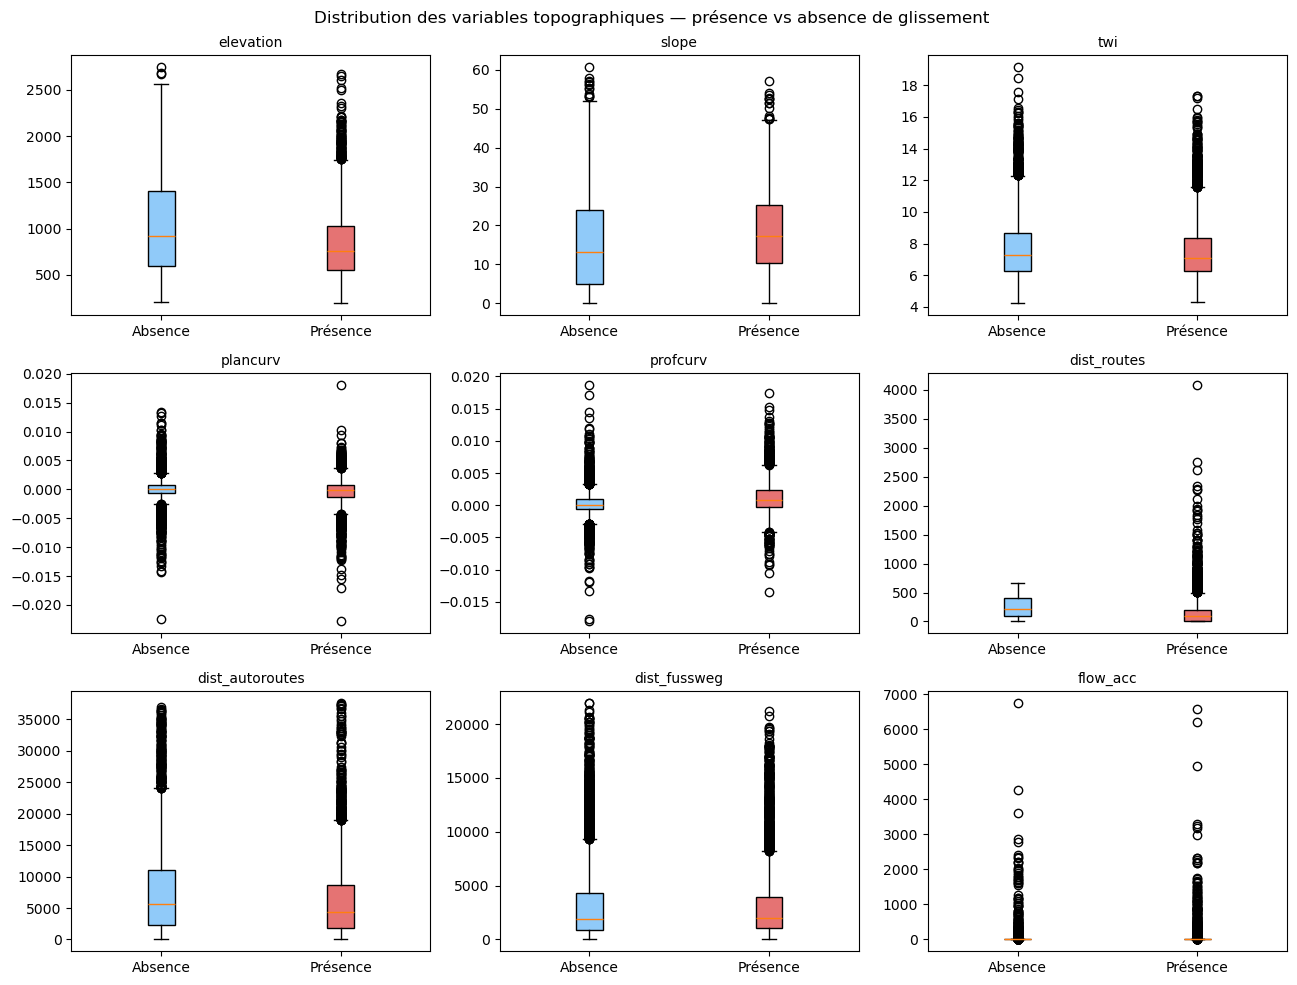

In [13]:
fig, axes = plt.subplots(3, 3, figsize=(13, 10))
couleurs = ['#90caf9', '#e57373']

for ax, col in zip(axes.ravel(), VARIABLES.keys()):
    groupes = [df.loc[df['label'] == 0, col], df.loc[df['label'] == 1, col]]
    bp = ax.boxplot(groupes, tick_labels=['Absence', 'Présence'], patch_artist=True)
    for patch, couleur in zip(bp['boxes'], couleurs):
        patch.set_facecolor(couleur)
    ax.set_title(col, fontsize=10)

plt.suptitle("Distribution des variables topographiques — présence vs absence de glissement", fontsize=12)
plt.tight_layout()
plt.show()

### 3.6 Choix du mode de validation : régions comme groupes

Un partage aléatoire (train/test) mélangerait des points de toutes les régions dans les deux jeux : le modèle pourrait alors apprendre des particularités régionales (un certain type de géologie, un climat local) et sembler bien fonctionner simplement parce qu'il a déjà vu des points très proches — géographiquement et statistiquement — de ceux du test. Comme les processus de glissement diffèrent entre Alpes, Préalpes, Jura et Plateau (§2), on préfère une validation **par région** : `LeaveOneGroupOut` entraîne le modèle sur 3 régions et l'évalue sur la 4ᵉ, jamais vue, et on répète l'opération pour chacune des 4 régions à tour de rôle. C'est une mesure plus honnête de la capacité du modèle à généraliser à un nouveau territoire — au prix d'un jeu d'évaluation plus petit à chaque tour.

In [15]:
FEATURES = [c for c in df.columns if c not in ('label', 'region')]
X = df[FEATURES].values.astype(float)
y = df['label'].values
groups = df['region'].values

logo = LeaveOneGroupOut()
print(f"Nombre de variables (9 continues + indicatrices géologie/occupation du sol) : {len(FEATURES)}")
print(f"Nombre de folds (= nombre de régions) : {logo.get_n_splits(groups=groups)}")
for region_test in df['region'].unique():
    n_train = (groups != region_test).sum()
    n_test  = (groups == region_test).sum()
    print(f"  Fold '{region_test}' en test : entraînement sur {n_train} points, test sur {n_test} points")

Nombre de variables (9 continues + indicatrices géologie/occupation du sol) : 27
Nombre de folds (= nombre de régions) : 4
  Fold 'Alps' en test : entraînement sur 3491 points, test sur 3970 points
  Fold 'Plateau' en test : entraînement sur 5623 points, test sur 1838 points
  Fold 'Pre-Alps' en test : entraînement sur 6363 points, test sur 1098 points
  Fold 'Jura' en test : entraînement sur 6906 points, test sur 555 points


---
## 4. Entraînement des modèles et quantification des erreurs

On compare un modèle **paramétrique simple** (régression logistique — un GLM, comme au TP-PY03) à un modèle **non-paramétrique** (XGBoost, comme au TP-PY04), avec la même procédure d'évaluation pour les deux.

### 4.1 Boucle de validation croisée par région

À chaque tour, on standardise et on entraîne les deux modèles uniquement sur les 3 régions d'entraînement (jamais sur la région de test), puis on prédit sur la région laissée de côté. On conserve à la fois les métriques par région et les prédictions *hors-échantillon* (chaque point est prédit une seule fois, quand sa région est le fold de test) pour une évaluation globale poolée.

In [16]:
resultats_par_region = []
oof_index, oof_true, oof_region = [], [], []
oof_pred_lr, oof_proba_lr = [], []
oof_pred_xgb, oof_proba_xgb = [], []

for train_idx, test_idx in logo.split(X, y, groups):
    region_test = groups[test_idx][0]
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    scaler = StandardScaler().fit(X_train)
    logreg = LogisticRegression(max_iter=1000).fit(scaler.transform(X_train), y_train)
    proba_lr = logreg.predict_proba(scaler.transform(X_test))[:, 1]
    pred_lr  = (proba_lr >= 0.5).astype(int)

    xgb_clf = xgb.XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, random_state=42, eval_metric='logloss',
    ).fit(X_train, y_train)
    proba_xgb = xgb_clf.predict_proba(X_test)[:, 1]
    pred_xgb  = (proba_xgb >= 0.5).astype(int)

    resultats_par_region.append({
        'Région':          region_test,
        'n (test)':        len(test_idx),
        'Exactitude LR':   accuracy_score(y_test, pred_lr),
        'AUC LR':          roc_auc_score(y_test, proba_lr),
        'Exactitude XGB':  accuracy_score(y_test, pred_xgb),
        'AUC XGB':         roc_auc_score(y_test, proba_xgb),
    })

    oof_index.extend(test_idx); oof_true.extend(y_test); oof_region.extend([region_test] * len(test_idx))
    oof_pred_lr.extend(pred_lr); oof_proba_lr.extend(proba_lr)
    oof_pred_xgb.extend(pred_xgb); oof_proba_xgb.extend(proba_xgb)

resultats_region_df = pd.DataFrame(resultats_par_region).set_index('Région').round(3)
resultats_region_df

,n (test),Exactitude LR,AUC LR,Exactitude XGB,AUC XGB
Région,,,,,
Alps,3970,0.678,0.734,0.746,0.812
Jura,555,0.739,0.811,0.757,0.849
Plateau,1838,0.711,0.774,0.766,0.847
Pre-Alps,1098,0.674,0.729,0.739,0.808


### 4.2 Résultats par région

Les métriques varient nettement d'une région à l'autre : c'est exactement l'information qu'un partage aléatoire aurait masquée en mélangeant les régions.

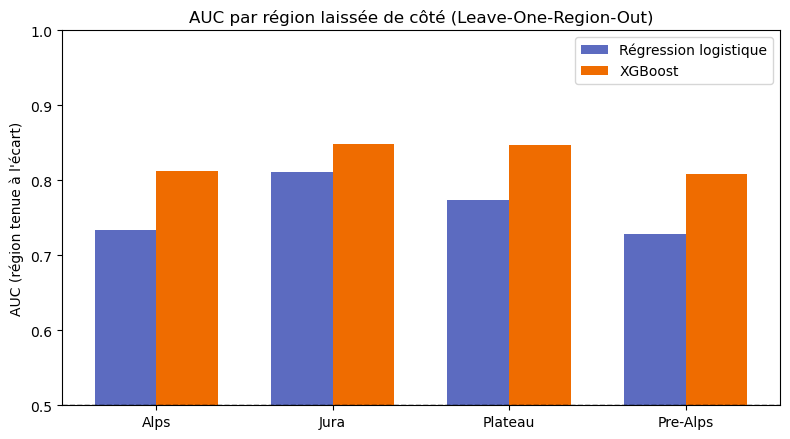

In [17]:
fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(resultats_region_df))
largeur = 0.35
ax.bar(x - largeur/2, resultats_region_df['AUC LR'],  largeur, label='Régression logistique', color='#5c6bc0')
ax.bar(x + largeur/2, resultats_region_df['AUC XGB'], largeur, label='XGBoost', color='#ef6c00')
ax.set_xticks(x)
ax.set_xticklabels(resultats_region_df.index)
ax.set_ylabel('AUC (région tenue à l\'écart)')
ax.set_ylim(0.5, 1.0)
ax.axhline(0.5, color='black', linestyle='--', linewidth=1)
ax.set_title("AUC par région laissée de côté (Leave-One-Region-Out)")
ax.legend()
plt.tight_layout()
plt.show()

### 4.3 Quantification globale de l'erreur (prédictions hors-échantillon poolées)

En rassemblant les prédictions hors-échantillon des 4 tours (chaque point prédit une seule fois, jamais par un modèle qui l'a vu à l'entraînement), on obtient une évaluation globale, comparable en format à un split classique : **exactitude**, **précision**, **rappel**, **F1**, et **AUC**.

In [18]:
def evaluer(y_vrai, y_pred, y_proba, nom):
    return {
        'Modèle':     nom,
        'Exactitude': accuracy_score(y_vrai, y_pred),
        'Précision':  precision_score(y_vrai, y_pred),
        'Rappel':     recall_score(y_vrai, y_pred),
        'F1':         f1_score(y_vrai, y_pred),
        'AUC':        roc_auc_score(y_vrai, y_proba),
    }

oof_true = np.array(oof_true)
resultats = pd.DataFrame([
    evaluer(oof_true, oof_pred_lr,  oof_proba_lr,  'Régression logistique'),
    evaluer(oof_true, oof_pred_xgb, oof_proba_xgb, 'XGBoost'),
]).set_index('Modèle').round(3)

resultats

,Exactitude,Précision,Rappel,F1,AUC
Modèle,,,,,
Régression logistique,0.690,0.676,0.730,0.702,0.738
XGBoost,0.751,0.758,0.738,0.747,0.821


### 4.4 Matrices de confusion et courbes ROC (poolées)

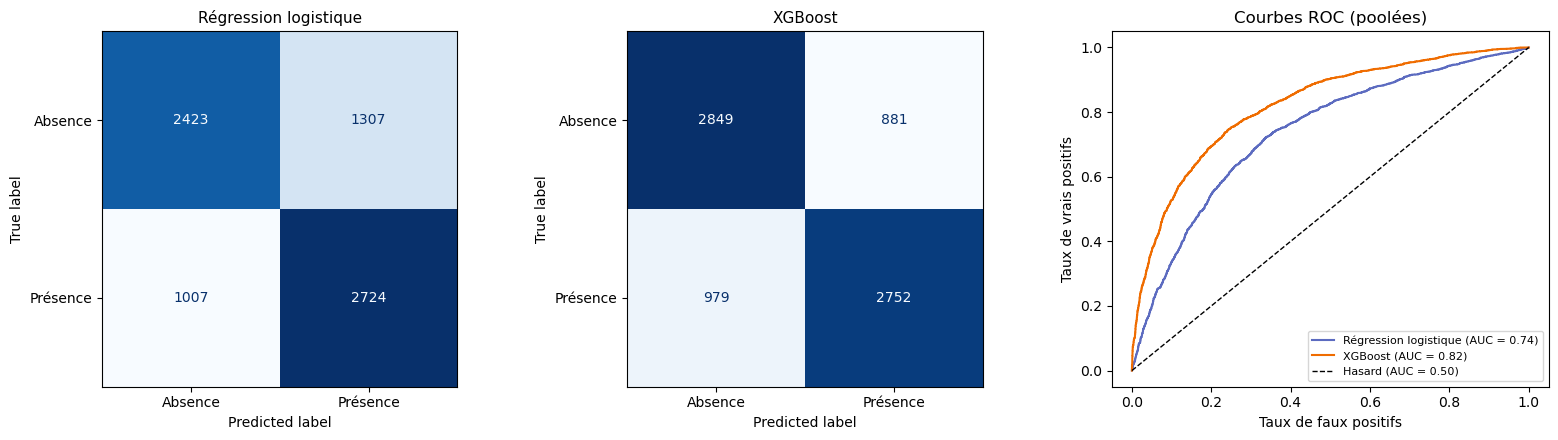

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, pred, titre in [
    (axes[0], oof_pred_lr,  'Régression logistique'),
    (axes[1], oof_pred_xgb, 'XGBoost'),
]:
    ConfusionMatrixDisplay.from_predictions(
        oof_true, pred, display_labels=['Absence', 'Présence'],
        cmap='Blues', ax=ax, colorbar=False,
    )
    ax.set_title(titre, fontsize=11)

for proba, nom, couleur in [
    (oof_proba_lr,  'Régression logistique', '#5c6bc0'),
    (oof_proba_xgb, 'XGBoost',               '#ef6c00'),
]:
    fpr, tpr, _ = roc_curve(oof_true, proba)
    auc = roc_auc_score(oof_true, proba)
    axes[2].plot(fpr, tpr, label=f'{nom} (AUC = {auc:.2f})', color=couleur)
axes[2].plot([0, 1], [0, 1], color='black', linestyle='--', linewidth=1, label='Hasard (AUC = 0.50)')
axes[2].set_xlabel('Taux de faux positifs')
axes[2].set_ylabel('Taux de vrais positifs')
axes[2].set_title('Courbes ROC (poolées)')
axes[2].legend(loc='lower right', fontsize=8)

plt.tight_layout()
plt.show()

### 4.5 Modèle final et importance des variables

La validation croisée sert à **estimer l'erreur de généralisation** (§4.1–4.4) ; une fois cette estimation obtenue, on ré-entraîne un dernier modèle sur **toutes** les données disponibles (aucune région exclue), pour l'interprétation des variables et la carte de probabilité ci-dessous — c'est ce modèle final qui serait utilisé en pratique.

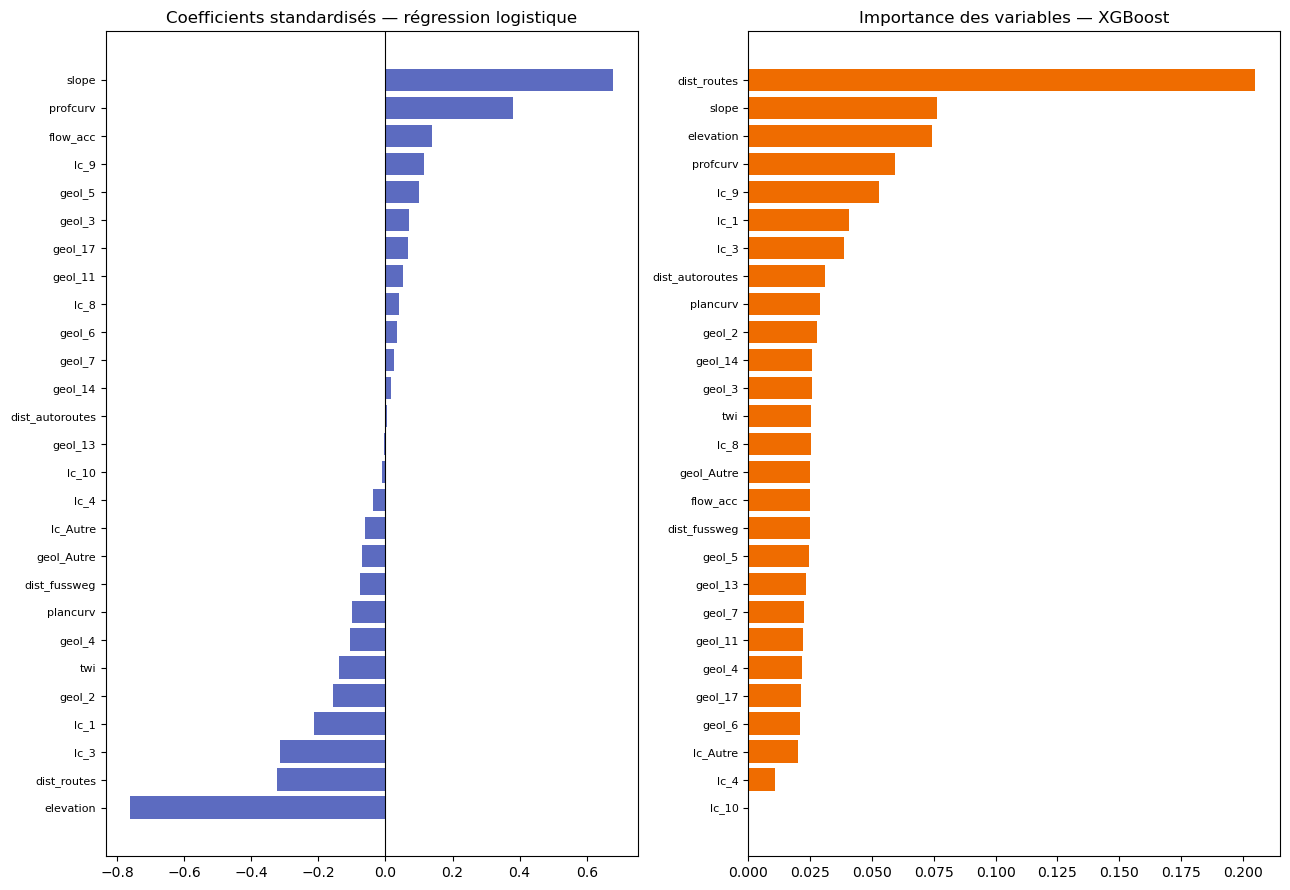

In [20]:
scaler_final = StandardScaler().fit(X)
logreg_final = LogisticRegression(max_iter=1000).fit(scaler_final.transform(X), y)
xgb_final = xgb.XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, random_state=42, eval_metric='logloss',
).fit(X, y)

coefs_lr = pd.Series(logreg_final.coef_[0], index=FEATURES).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(13, 9))
axes[0].barh(coefs_lr.index, coefs_lr.values, color='#5c6bc0')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Coefficients standardisés — régression logistique')
axes[0].tick_params(axis='y', labelsize=8)

imp_xgb = pd.Series(xgb_final.feature_importances_, index=FEATURES).sort_values()
axes[1].barh(imp_xgb.index, imp_xgb.values, color='#ef6c00')
axes[1].set_title('Importance des variables — XGBoost')
axes[1].tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.show()

### 4.6 Carte des probabilités prédites (hors-échantillon, XGBoost)

Pour rester honnête, la carte utilise les probabilités **hors-échantillon** de §4.1 (chaque point prédit par un modèle qui n'a jamais vu sa région), pas le modèle final — sinon les glissements utilisés à l'entraînement paraîtraient artificiellement bien classés.

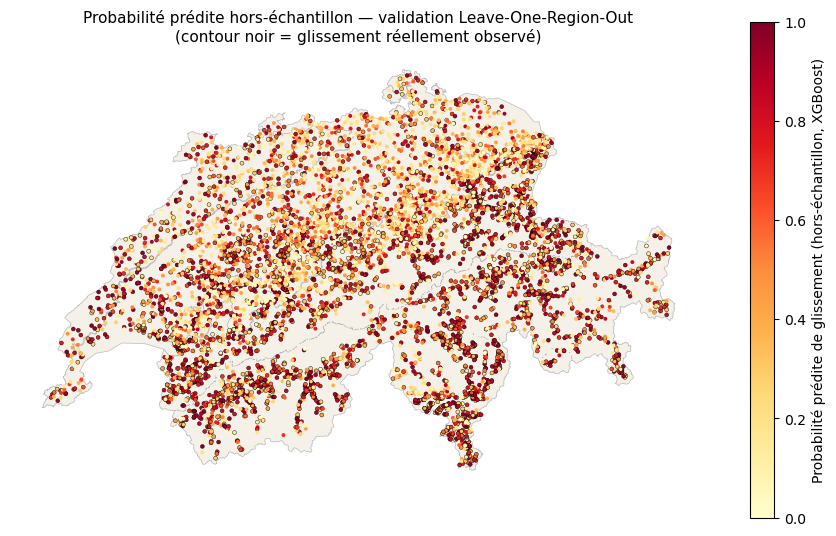

In [21]:
fig, ax = plt.subplots(figsize=(9, 6.5))
for _, row in regions.iterrows():
    gpd.GeoSeries([row.geometry], crs=regions.crs).plot(
        ax=ax, color='#f5f0e8', edgecolor='#bbb', linewidth=0.5,
    )
sc = ax.scatter(
    points_all.geometry.x, points_all.geometry.y,
    c=oof_proba_xgb, cmap='YlOrRd', vmin=0, vmax=1, s=8,
    edgecolors=np.where(oof_true == 1, 'black', 'none'), linewidths=0.3,
)
plt.colorbar(sc, ax=ax, label='Probabilité prédite de glissement (hors-échantillon, XGBoost)', shrink=0.8)
ax.set_title('Probabilité prédite hors-échantillon — validation Leave-One-Region-Out\n'
             '(contour noir = glissement réellement observé)', fontsize=11)
ax.set_axis_off()
plt.tight_layout()
plt.show()

---
## 5. Export des résultats

Vecteurs de contexte et rasters étaient déjà dans `project_landslides.gpkg` avant même d'ouvrir ce notebook (§1) : il ne reste qu'à y ajouter les résultats de la classification. On **remplace** la couche `classification_points` (déjà présente, issue d'une exécution précédente) plutôt que de réécrire tout le fichier — GeoPackage permet de mettre à jour une seule couche sans toucher aux autres.

In [22]:
resultats_points = points_all.copy()
resultats_points['region']          = df['region'].values
resultats_points['label']           = df['label'].values
resultats_points['oof_proba_lr']    = oof_proba_lr
resultats_points['oof_proba_xgb']   = oof_proba_xgb
resultats_points['proba_lr_final']  = logreg_final.predict_proba(scaler_final.transform(X))[:, 1]
resultats_points['proba_xgb_final'] = xgb_final.predict_proba(X)[:, 1]

resultats_points.to_file(GPKG, layer='classification_points', driver='GPKG')

print(f"Couche 'classification_points' mise à jour dans {GPKG} ({len(resultats_points)} points)")
print(f"\nContenu complet de {GPKG} :")
for layer in gpd.list_layers(GPKG)['name']:
    print(' -', layer, '(vecteur)')
for table in RASTER_TABLES:
    print(' -', table, '(raster)')

Couche 'classification_points' mise à jour dans project_landslides.gpkg (7461 points)

Contenu complet de project_landslides.gpkg :
 - switzerland (vecteur)
 - regions (vecteur)
 - landslides_ch (vecteur)
 - cities (vecteur)
 - lakes (vecteur)
 - classification_points (vecteur)
 - dem (raster)
 - slope (raster)
 - twi (raster)
 - plancurv (raster)
 - profcurv (raster)
 - dist_routes (raster)
 - dist_autoroutes (raster)
 - dist_fussweg (raster)
 - flow_acc (raster)
 - flow_dir (raster)
 - geology (raster)
 - landcover (raster)
 - scp_map (raster)
